In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Arial'

import warnings
warnings.filterwarnings('ignore')

In [4]:
cd C:\Users\tr432\Desktop\Roh\_Study_Design\25.05.02~_Gut-Lung_Axis\Exp1+1-S\MGX\04.kraken2.out\bracken\genus

C:\Users\tr432\Desktop\Roh\_Study_Design\25.05.02~_Gut-Lung_Axis\Exp1+1-S\MGX\04.kraken2.out\bracken\genus


In [5]:
feat = 'Lactobacillus'

orders = ['Control', 'VNAM']

q_val = 0.0247033525692286

outname = feat.replace('/', '-').replace(' ', '_')

In [6]:
df = pd.read_excel('genus_merged_frac_tp.xlsx', sheet_name='1')

data = df[['name', 'Group', feat]].copy()
data[feat] = pd.to_numeric(data[feat], errors='coerce')
data = data.dropna(subset=['Group', feat])
data = data[data['Group'].isin(orders)].copy()

print(data)
print(data.groupby('Group')[feat].agg(['count', 'mean', 'sem']))

      name    Group  Lactobacillus
0   C01-2w  Control        0.02703
1   C02-2w  Control        0.04921
2   C03-2w  Control        0.03430
3   C09-2w  Control        0.00391
4   C10-2w  Control        0.01340
5   C11-2w  Control        0.11215
6   V01-2w     VNAM        0.00006
7   V02-2w     VNAM        0.00004
8   V03-2w     VNAM        0.00006
9   V04-2w     VNAM        0.00002
10  V05-2w     VNAM        0.00005
11  V06-2w     VNAM        0.00004
12  V07-2w     VNAM        0.00002
13  V08-2w     VNAM        0.00005
14  V10-2w     VNAM        0.00009
         count      mean       sem
Group                             
Control      6  0.040000  0.015813
VNAM         9  0.000048  0.000007


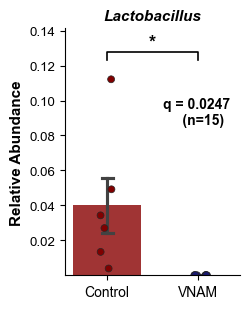

In [12]:
g_colors = ['firebrick', 'royalblue']
d_colors = ['maroon', 'midnightblue']

plt.figure(figsize=(2.6, 3.2))

ax = sns.barplot(data=data, x='Group', y=feat, order=orders, estimator='mean', errorbar='se', capsize=0.12, palette=g_colors, width=0.75)

sns.stripplot(data=data, x='Group', y=feat, order=orders, jitter=True, edgecolor='gray', linewidth=0.5, palette=d_colors, size=5.0, zorder=2)


def q_to_star(q):
    if pd.isna(q):
        return 'NA'
    elif q < 0.0001:
        return '****'
    elif q < 0.001:
        return '***'
    elif q < 0.01:
        return '**'
    elif q < 0.05:
        return '*'
    else:
        return 'ns'


star = q_to_star(q_val)

# bracket 위치 설정
x1, x2 = 0, 1   # Control, VNAM 위치
y_max = data[feat].max()
y_min = data[feat].min()
y_range = y_max - y_min if y_max > y_min else 1

bracket_y = y_max + y_range * 0.10
bracket_h = y_range * 0.04
text_y = bracket_y + bracket_h + y_range * 0.00

# bracket 그리기
ax.plot([x1, x1, x2, x2], [bracket_y, bracket_y + bracket_h, bracket_y + bracket_h, bracket_y], color='black', linewidth=1.2)

# 별표/q-value 표시
ax.text((x1 + x2) / 2, text_y, star, ha='center', va='bottom', fontsize=13, fontweight='bold' if star != 'ns' else 'normal', color='black')

plt.ylim(y_min, text_y + y_range * 0.12)


leg = plt.legend([], [], title=f"q = {q_val:.3g}\n     (n={len(data)})", loc=[0.53, 0.55], frameon=False, title_fontsize=10)
leg.get_title().set_fontweight('bold')


plt.xlabel('')
plt.ylabel('Relative Abundance', fontsize=11, fontweight='bold')
plt.title(feat, fontsize=11, fontweight='bold', fontstyle='italic')

plt.xticks(orders, fontsize=10)
plt.yticks(fontsize=9.5)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{outname}_barplot.png', dpi=500, bbox_inches='tight')
plt.show()